In [1]:
import asyncio
import json
import time
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
from datetime import datetime
from pathlib import Path
import os
import sys

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
vna.go_to_local()

Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


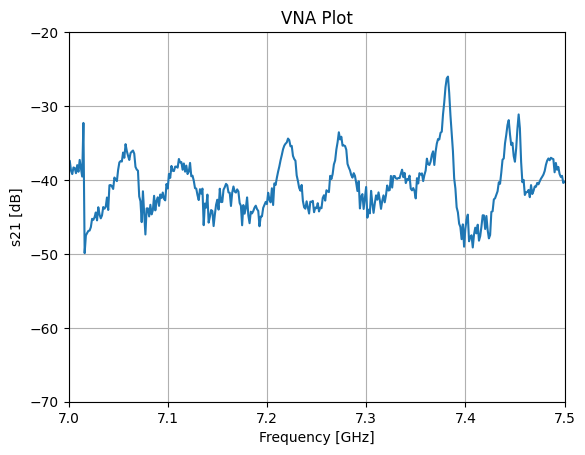

In [12]:
vna_trace = {}

vna_trace['idn'] = vna.query('*IDN?')
vna_trace['vna_start_frequency']    = float(vna.query(':SENS1:FREQ:START?'))
vna_trace['vna_stop_frequency']     = float(vna.query(':SENS1:FREQ:STOP?'))
vna_trace['vna_number_of_points'] = int(vna.query(':SENS1:SWEep:POINts?'))
vna_trace['ifbw']      = float(vna.query(':SENS1:BAND?'))
vna_trace['power']      = float(vna.query('SOURce1:POWer?'))
frequencies = np.linspace(vna_trace['vna_start_frequency'],vna_trace['vna_stop_frequency'],vna_trace['vna_number_of_points'])
fghz = frequencies/1e9

now = datetime.now().astimezone()
vna_trace['timestamp'] = int(now.timestamp())
vna_trace['date'] = now.strftime("%d-%m-%Y")
vna_trace['time'] = now.strftime("%H:%M:%S")
vna_trace['timezone'] = now.tzname()

vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
vna.write("FORM REAL,32") 
vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
vna.write("INITiate:CONTinuous OFF")
vna.write("INITiate:IMMediate")  
opc_done = vna.query("*OPC?").strip()    
if opc_done != "1":
    print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
    exit()
raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
vna.write("INITiate:CONTinuous ON")
vna.go_to_local()

real_parts = np.array(raw_floats[0::2])
imag_parts = np.array(raw_floats[1::2])
complex_trace = real_parts + 1j * imag_parts
s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
s_matrix[:, 0, 0] = complex_trace
trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
trace = trace_network.s_db[:,0,0]

vna_trace['db'] = trace.tolist()
vna_trace['fghz'] = fghz.tolist()
plt.plot(fghz, trace)
plt.xlim(fghz[0], fghz[-1])
plt.ylim(-70,-20)
plt.title('VNA Plot')
plt.grid()
plt.xlabel('Frequency [GHz]')
plt.ylabel('s21 [dB]')
plot_file_name = f"{vna_trace['timestamp']}-vna-plot.png"
plt.savefig(plot_file_name, dpi=300, bbox_inches='tight')
touchstone_file_name = f"{vna_trace['timestamp']}-vna-trace.s1p"
trace_network.write_touchstone(touchstone_file_name)

json_file_name = f"{vna_trace['timestamp']}-trace.json"

with open(json_file_name, "w", encoding="utf-8") as f:
    json.dump(vna_trace, f, indent=4)
